<a href="https://colab.research.google.com/github/UmeshaNugegoda/Final-Year-Project-EYE-CARE-/blob/main/project_from_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost imbalanced-learn openpyxl easyocr --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 22.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import re
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_val_score, GridSearchCV)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       accuracy_score, f1_score,
                                       ConfusionMatrixDisplay)
from sklearn.pipeline         import Pipeline
from sklearn.impute            import SimpleImputer
from xgboost                  import XGBClassifier
from imblearn.over_sampling   import SMOTE
from google.colab             import files, drive

print("All libraries imported")

All libraries imported


In [ ]:
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/eye_correction_model"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save folder ready: {SAVE_DIR}")

Mounted at /content/drive
Save folder ready: /content/drive/MyDrive/eye_correction_model


In [ ]:
print("Upload your Excel dataset..")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df       = pd.read_excel(filename)

print(f"Loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Upload your Excel dataset..


Saving eye_correction_dataset_v3.xlsx to eye_correction_dataset_v3.xlsx
Loaded: (404, 9)
Columns: ['K1_Flat', 'astigmatism_diopters', 'K2_Steep', 'corneal_thickness_um', 'sphere_diopters', 'cylinder_diopters', 'axis_degrees', 'visual_acuity_decimal', 'correction_type']


,K1_Flat,astigmatism_diopters,K2_Steep,corneal_thickness_um,sphere_diopters,cylinder_diopters,axis_degrees,visual_acuity_decimal,correction_type
0,45.43,0.97,46.40,566.0,-8.50,-2.00,40.0,0.66,Spectacles
1,46.85,1.35,48.20,596.6,2.60,1.01,79.0,0.31,Spectacles
2,42.17,1.55,43.72,507.2,1.75,-1.14,42.0,0.05,Contact Lenses
3,43.66,0.53,44.19,585.2,0.42,-0.05,76.0,1.15,No Correction
4,43.62,1.11,44.73,531.0,6.10,-0.95,115.0,0.49,Spectacles


In [ ]:
TARGET_COL     = "correction_type"
VA_SNELLEN_COL = "visual_acuity"  #column with "6/9" values
VA_DECIMAL_COL = "visual_acuity_decimal" #column with 0.67 values
K1_COL         = "K1_diopters"
ASTIG_COL      = "astigmatism_diopters"
K2_COL         = "K2_diopters"

assert TARGET_COL in df.columns, \
    f" '{TARGET_COL}' not found! Available: {list(df.columns)}"

print(f" Target : {TARGET_COL}")
print(f"  Classes:\n{df[TARGET_COL].value_counts().to_string()}")

 Target : correction_type
  Classes:
correction_type
Spectacles        197
Contact Lenses    129
No Correction      78


In [ ]:
SNELLEN_TABLE = {
    '6/4':1.50,'6/5':1.20,'6/6':1.00,'6/7.5':0.80,'6/9':0.67,
    '6/12':0.50,'6/18':0.33,'6/24':0.25,'6/36':0.17,'6/60':0.10,
    '3/60':0.05,'1/60':0.02,
    '20/20':1.00,'20/40':0.50,'20/200':0.10,
}

def snellen_to_decimal(value):
    """
    Convert Snellen notation to decimal visual acuity.
    '6/9' → 0.67  |  '6/18' → 0.33  |  0.67 → 0.67 (passthrough)
    """
    if pd.isna(value): return np.nan
    if isinstance(value, (int, float)): return round(float(value), 2)
    value = str(value).strip()
    if value in SNELLEN_TABLE: return SNELLEN_TABLE[value]
    m = re.match(r'^(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)$', value)
    if m:
        num, den = float(m.group(1)), float(m.group(2))
        return round(num / den, 2) if den != 0 else np.nan
    print(f" Cannot convert: '{value}' → NaN")
    return np.nan

def calculate_k2(k1, astig):
    """
    Calculate K2 from K1 and corneal astigmatism.
    K2 = K1 + |astigmatism|
    K2 is always the steeper corneal meridian — never entered manually.
    """
    if pd.isna(k1) or pd.isna(astig): return np.nan
    return round(float(k1) + abs(float(astig)), 2)

# Apply conversions to dataframe
print("Applying conversions...\n")

# A — Snellen VA → decimal
if VA_SNELLEN_COL and VA_SNELLEN_COL in df.columns:
    print(f"  Converting '{VA_SNELLEN_COL}' → decimal...")
    df['visual_acuity_decimal'] = df[VA_SNELLEN_COL].apply(snellen_to_decimal)
    print(f"  Sample: {df[VA_SNELLEN_COL].head(3).tolist()} → "
          f"{df['visual_acuity_decimal'].head(3).tolist()}")
    VA_DECIMAL_COL = 'visual_acuity_decimal'
elif VA_DECIMAL_COL in df.columns:
    print(f"  '{VA_DECIMAL_COL}' already decimal — skipped")
else:
    print("No VA column found")

# B — Calculate K2
if K2_COL not in df.columns or df[K2_COL].isna().all():
    if K1_COL in df.columns and ASTIG_COL in df.columns:
        print(f"\n  Calculating K2 = {K1_COL} + |{ASTIG_COL}|...")
        df[K2_COL] = df.apply(
            lambda r: calculate_k2(r[K1_COL], r[ASTIG_COL]), axis=1
        )
        print(f"  Sample:\n{df[[K1_COL, ASTIG_COL, K2_COL]].head(4).to_string()}")
        assert (df[K2_COL] >= df[K1_COL]).all(), " Some K2 < K1 — check data!"
        print("All K2 >= K1")
else:
    print(f"  '{K2_COL}' already exists — skipped")

print("\n Conversions done")

Applying conversions...

  'visual_acuity_decimal' already decimal — skipped

 Conversions done


  EXPLORATORY DATA ANALYSIS

 Missing values:
K1_Flat                   1
astigmatism_diopters      1
K2_Steep                  1
corneal_thickness_um      8
sphere_diopters           5
cylinder_diopters         9
axis_degrees             18
visual_acuity_decimal    12

 Duplicate rows: 0
   After removing duplicates: 404

 Descriptive statistics:
       K1_Flat  astigmatism_diopters  K2_Steep  corneal_thickness_um  sphere_diopters  cylinder_diopters  axis_degrees  visual_acuity_decimal
count  403.000               403.000   403.000               396.000          399.000            395.000       386.000                392.000
mean    44.647                 0.993    45.643               534.289            0.068              0.130        85.280                  0.497
std      1.524                 0.687     1.772                29.991            4.004              1.812        53.183                  0.317
min     38.480                -1.250    39.920               449.200           -9.

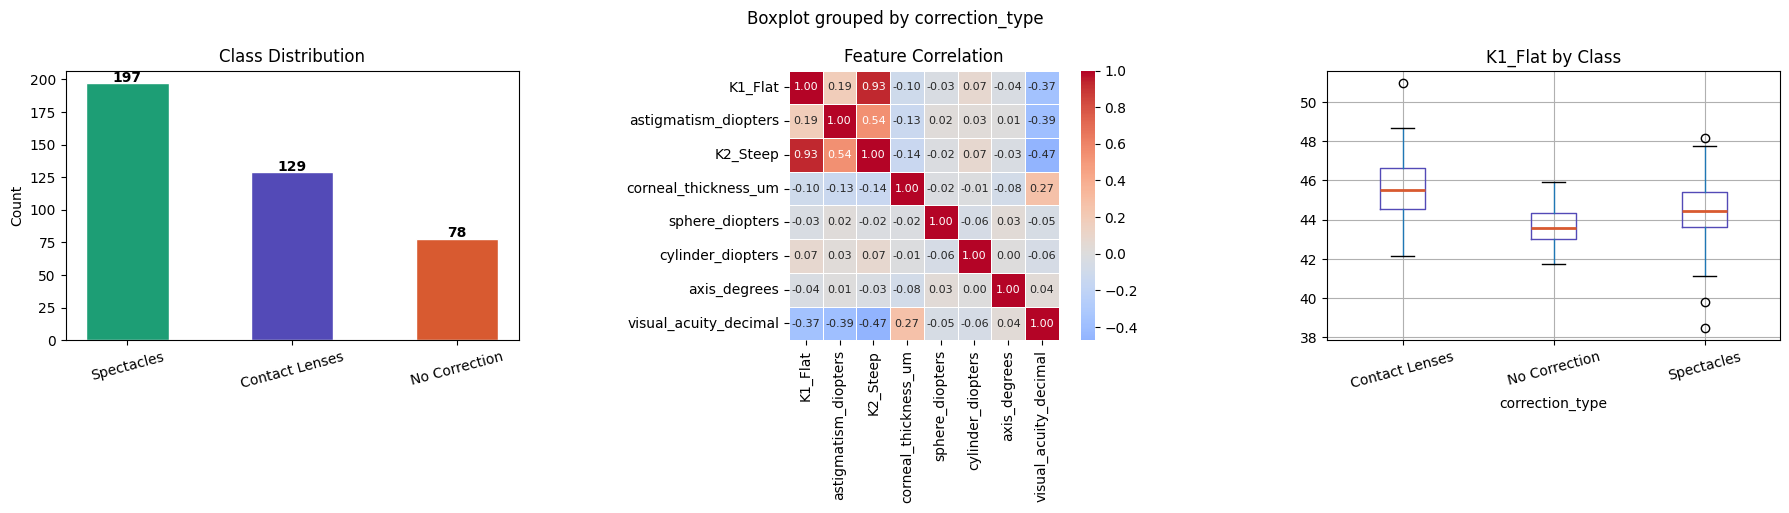

 EDA saved


In [ ]:
print("="*55)
print("  EXPLORATORY DATA ANALYSIS")
print("="*55)

missing = df.isnull().sum()
print("\n Missing values:")
print(missing[missing > 0].to_string() if missing.any() else "  None")

print("\n Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("   After removing duplicates:", len(df))

print("\n Descriptive statistics:")
print(df.describe().round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Eye Correction Dataset", fontsize=14, fontweight='bold')

counts = df[TARGET_COL].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#1D9E75','#534AB7','#D85A30'],
            edgecolor='white', width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i,v in enumerate(counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Correlation heatmap
num_cols = df.select_dtypes(include='number').columns.tolist()
sns.heatmap(df[num_cols].corr(), ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size':8}, square=True)
axes[1].set_title("Feature Correlation")

if num_cols:
    df.boxplot(column=num_cols[0], by=TARGET_COL, ax=axes[2],
               boxprops=dict(color='#534AB7'),
               medianprops=dict(color='#D85A30', linewidth=2))
    axes[2].set_title(f"{num_cols[0]} by Class")
    plt.sca(axes[2]); plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/eda.png", dpi=150, bbox_inches='tight')
plt.show()
print(" EDA saved")

In [ ]:
print("Preprocessing...")

le = LabelEncoder()
y  = pd.Series(le.fit_transform(df[TARGET_COL]), name=TARGET_COL)
print(f"  Labels: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Drop label + Snellen string (model uses decimal only)
drop_cols = [TARGET_COL]
if VA_SNELLEN_COL and VA_SNELLEN_COL in df.columns:
    drop_cols.append(VA_SNELLEN_COL)

X             = df.drop(columns=drop_cols).select_dtypes(include='number')
FEATURE_NAMES = list(X.columns)

print(f"  Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
print(f"  Samples : {len(X)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")
print("Preprocessing done")

Preprocessing...
  Labels: {'Contact Lenses': np.int64(0), 'No Correction': np.int64(1), 'Spectacles': np.int64(2)}
  Features (8): ['K1_Flat', 'astigmatism_diopters', 'K2_Steep', 'corneal_thickness_um', 'sphere_diopters', 'cylinder_diopters', 'axis_degrees', 'visual_acuity_decimal']
  Samples : 404
  Train: (323, 8)  |  Test: (81, 8)
Preprocessing done


In [ ]:
print(" SMOTE balancing (train set only)...")

imputer     = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_NAMES)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=FEATURE_NAMES)

print(f"  Before: {dict(y_train.value_counts().sort_index())}")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)
print(f"  After : {dict(pd.Series(y_train_bal).value_counts().sort_index())}")
print(" Balancing done")

 SMOTE balancing (train set only)...
  Before: {0: np.int64(103), 1: np.int64(62), 2: np.int64(158)}
  After : {0: np.int64(158), 1: np.int64(158), 2: np.int64(158)}
 Balancing done


  MODEL COMPARISON

  Random Forest
    CV F1  : 0.8890 ± 0.0297
    Test Acc: 0.8272  |  Test F1: 0.8263

  XGBoost
    CV F1  : 0.8841 ± 0.0137
    Test Acc: 0.8395  |  Test F1: 0.8381

  Gradient Boosting
    CV F1  : 0.8931 ± 0.0321
    Test Acc: 0.8272  |  Test F1: 0.8272

  Logistic Regression
    CV F1  : 0.8119 ± 0.0103
    Test Acc: 0.7284  |  Test F1: 0.7299

 Best model: XGBoost (F1=0.8381)


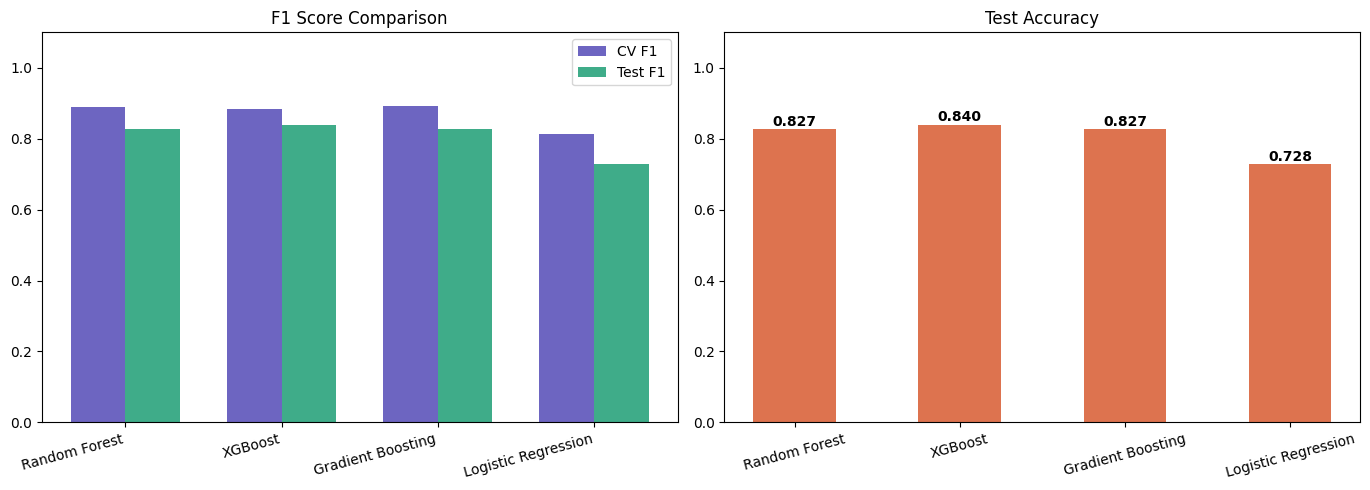

In [ ]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test_imp)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=4,
        class_weight='balanced', random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, eval_metric='mlogloss', random_state=42, verbosity=0
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced',
        solver='lbfgs', C=1.0, random_state=42
    ),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("="*60)
print("  MODEL COMPARISON")
print("="*60)

for name, clf in models.items():
    cv_scores = cross_val_score(clf, X_train_scaled, y_train_bal,
                                cv=cv, scoring='f1_weighted')
    clf.fit(X_train_scaled, y_train_bal)
    y_pred = clf.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')

    results[name] = dict(model=clf, cv_f1=cv_scores.mean(),
                         test_acc=acc, test_f1=f1)
    print(f"\n  {name}")
    print(f"    CV F1  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"    Test Acc: {acc:.4f}  |  Test F1: {f1:.4f}")

# Auto-select best
best_name  = max(results, key=lambda m: results[m]['test_f1'])
best_model = results[best_name]['model']
print(f"\n Best model: {best_name} (F1={results[best_name]['test_f1']:.4f})")

# Comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = list(results.keys())
x = np.arange(len(model_names)); w = 0.35
axes[0].bar(x-w/2,[results[m]['cv_f1']   for m in model_names],
            w, label='CV F1',   color='#534AB7', alpha=0.85)
axes[0].bar(x+w/2,[results[m]['test_f1'] for m in model_names],
            w, label='Test F1', color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylim(0,1.1); axes[0].legend()
axes[0].set_title("F1 Score Comparison")

accs = [results[m]['test_acc'] for m in model_names]
axes[1].bar(model_names, accs, color='#D85A30', alpha=0.85, width=0.5)
axes[1].set_ylim(0,1.1); axes[1].set_title("Test Accuracy")
axes[1].tick_params(axis='x', rotation=15)
for i,v in enumerate(accs):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f" Tuning: {best_name}...")

param_grids = {
    "Random Forest"     : {'n_estimators':[100,200,300],
                           'max_depth':[6,8,10,None],
                           'min_samples_split':[2,4,6]},
    "XGBoost"           : {'n_estimators':[100,200,300],
                           'learning_rate':[0.01,0.05,0.1],
                           'max_depth':[3,5,7],
                           'min_child_weight':[1,3,5]},
    "Gradient Boosting" : {'n_estimators':[100,150,200],
                           'learning_rate':[0.05,0.1,0.2],
                           'max_depth':[3,4,5]},
    "Logistic Regression": {'C':[0.01,0.1,1.0,10.0]},
}

grid = GridSearchCV(
    best_model, param_grids.get(best_name, {}),
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid.fit(X_train_scaled, y_train_bal)
tuned_model  = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

print(f"  Best params : {grid.best_params_}")
print(f"  Best CV F1  : {grid.best_score_:.4f}")
print(f"  Tuned Acc   : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Tuned F1    : {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(" Tuning done")

 Tuning: XGBoost...
  Best params : {'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 100}
  Best CV F1  : 0.9012
  Tuned Acc   : 0.8395
  Tuned F1    : 0.8381
 Tuning done


  FINAL EVALUATION

                precision    recall  f1-score   support

Contact Lenses       0.76      0.73      0.75        26
 No Correction       0.94      1.00      0.97        16
    Spectacles       0.85      0.85      0.85        39

      accuracy                           0.84        81
     macro avg       0.85      0.86      0.85        81
  weighted avg       0.84      0.84      0.84        81



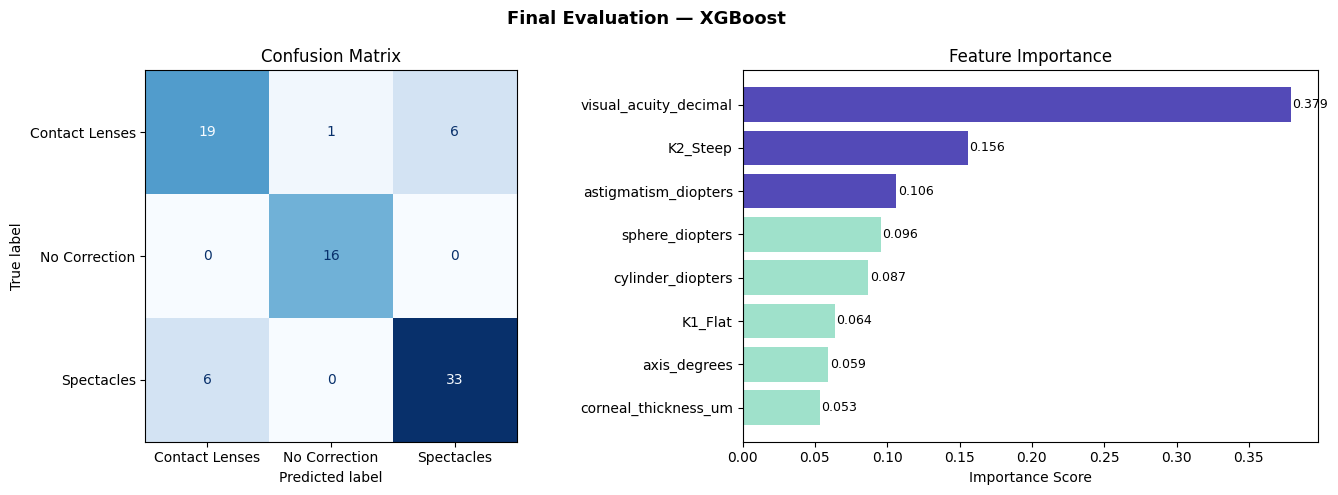

 Evaluation saved


In [ ]:
class_names  = list(le.classes_)
y_pred_final = tuned_model.predict(X_test_scaled)

print("="*55)
print("  FINAL EVALUATION")
print("="*55)
print(f"\n{classification_report(y_test, y_pred_final, target_names=class_names)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Final Evaluation — {best_name}", fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_final),
    display_labels=class_names
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix")

if hasattr(tuned_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature'   : FEATURE_NAMES,
        'Importance': tuned_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    colors = ['#534AB7' if i >= len(fi)-3 else '#9FE1CB' for i in range(len(fi))]
    axes[1].barh(fi['Feature'], fi['Importance'], color=colors)
    for i,(val,name) in enumerate(zip(fi['Importance'], fi['Feature'])):
        axes[1].text(val+0.001, i, f'{val:.3f}', va='center', fontsize=9)
    axes[1].set_title("Feature Importance")
    axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/final_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Evaluation saved")

In [ ]:
print(" Saving to Google Drive...")

joblib.dump(tuned_model,   f"{SAVE_DIR}/eye_correction_model.pkl")
joblib.dump(le,            f"{SAVE_DIR}/label_encoder.pkl")
joblib.dump(scaler,        f"{SAVE_DIR}/scaler.pkl")
joblib.dump(imputer,       f"{SAVE_DIR}/imputer.pkl")
joblib.dump(FEATURE_NAMES, f"{SAVE_DIR}/feature_names.pkl")

print("   eye_correction_model.pkl")
print("   label_encoder.pkl")
print("   scaler.pkl")
print("   imputer.pkl")
print("   feature_names.pkl")
print(f"\n All saved in: {SAVE_DIR}")

 Saving to Google Drive...
   eye_correction_model.pkl
   label_encoder.pkl
   scaler.pkl
   imputer.pkl
   feature_names.pkl

 All saved in: /content/drive/MyDrive/eye_correction_model


In [ ]:
def predict_patient(patient_data: dict) -> dict:
    """
    Test the trained model with one patient's values.

    Handles automatically:
      - Snellen VA  ('6/18') → decimal (0.33)
      - K2 = K1 + |astigmatism|  if K2 not provided
    """
    model_   = joblib.load(f"{SAVE_DIR}/eye_correction_model.pkl")
    le_      = joblib.load(f"{SAVE_DIR}/label_encoder.pkl")
    scaler_  = joblib.load(f"{SAVE_DIR}/scaler.pkl")
    imputer_ = joblib.load(f"{SAVE_DIR}/imputer.pkl")
    feats    = joblib.load(f"{SAVE_DIR}/feature_names.pkl")

    data = dict(patient_data)

    # Auto-convert Snellen VA
    if 'visual_acuity_snellen' in data:
        data['visual_acuity_decimal'] = snellen_to_decimal(
            data.pop('visual_acuity_snellen')
        )

    # Auto-calculate K2
    if 'K2_diopters' not in data or data.get('K2_diopters') is None:
        if 'K1_diopters' in data and 'astigmatism_diopters' in data:
            data['K2_diopters'] = calculate_k2(
                data['K1_diopters'], data['astigmatism_diopters']
            )

    row     = pd.DataFrame([{f: data.get(f, np.nan) for f in feats}])
    row_imp = imputer_.transform(row)
    row_sc  = scaler_.transform(row_imp)
    idx     = model_.predict(row_sc)[0]
    probs   = model_.predict_proba(row_sc)[0]

    return {
        'prediction'   : le_.inverse_transform([idx])[0],
        'confidence'   : f"{max(probs)*100:.1f}%",
        'probabilities': {c: f"{p*100:.1f}%" for c,p in zip(le_.classes_, probs)}
    }

# Test with a sample patient
sample = {
    'K1_diopters'          : 45.5,
    'astigmatism_diopters' : 1.2,
    'corneal_thickness_um' : 510,
    'sphere_diopters'      : -4.5,
    'cylinder_diopters'    : -1.5,
    'axis_degrees'         : 90,
    'visual_acuity_snellen': '6/18',   # auto-converted → 0.33
}

result = predict_patient(sample)
print("\n" + "="*42)
print("  SAMPLE PREDICTION")
print("="*42)
print(f"  Prediction   : {result['prediction']}")
print(f"  Confidence   : {result['confidence']}")
print(f"  Probabilities:")
for cls, prob in result['probabilities'].items():
    print(f"    {cls:20s}: {prob}")



  SAMPLE PREDICTION
  Prediction   : Contact Lenses
  Confidence   : 52.9%
  Probabilities:
    Contact Lenses      : 52.9%
    No Correction       : 3.0%
    Spectacles          : 44.1%


In [ ]:
files.download(f"{SAVE_DIR}/eye_correction_model.pkl")
files.download(f"{SAVE_DIR}/label_encoder.pkl")
files.download(f"{SAVE_DIR}/scaler.pkl")
files.download(f"{SAVE_DIR}/imputer.pkl")
files.download(f"{SAVE_DIR}/feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>